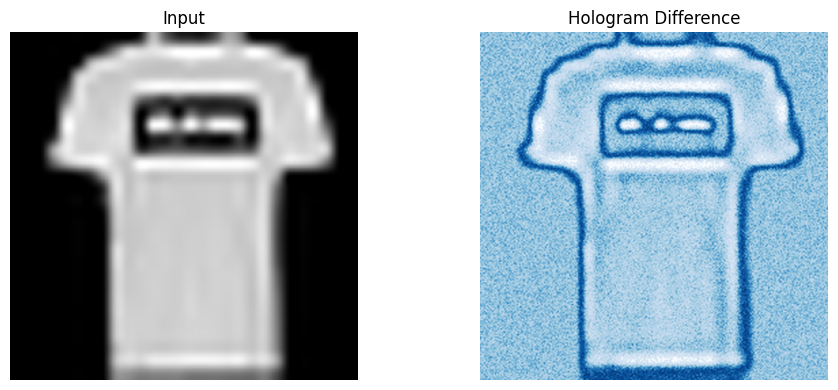

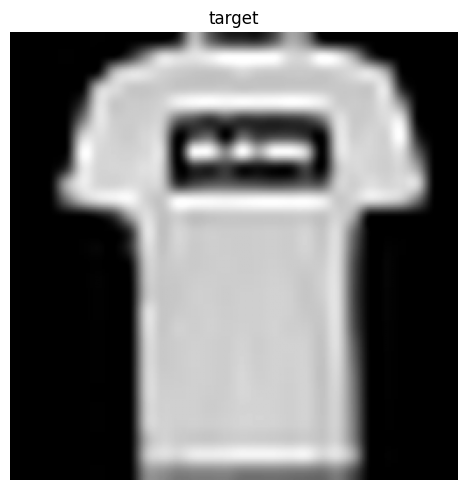

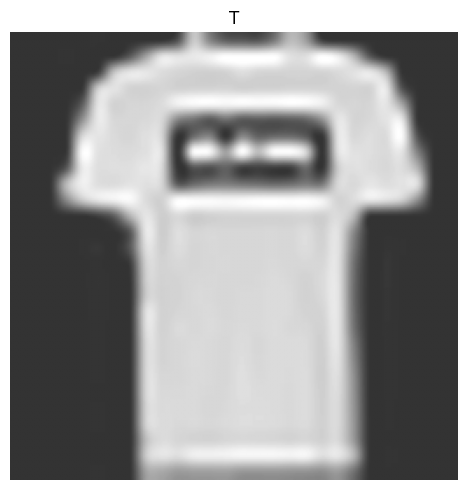

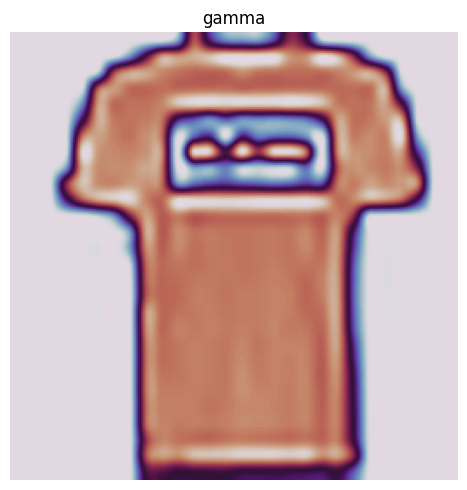

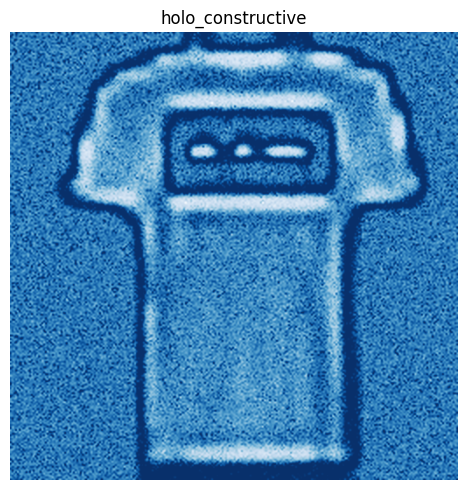

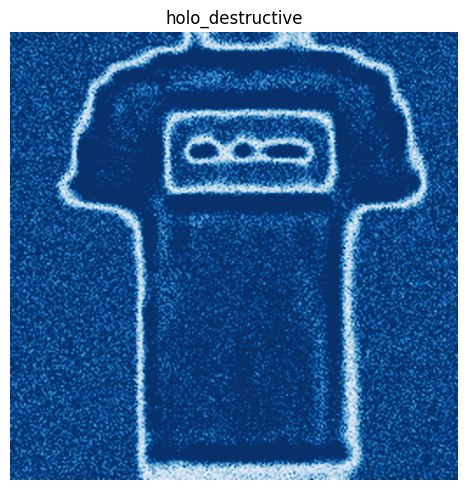

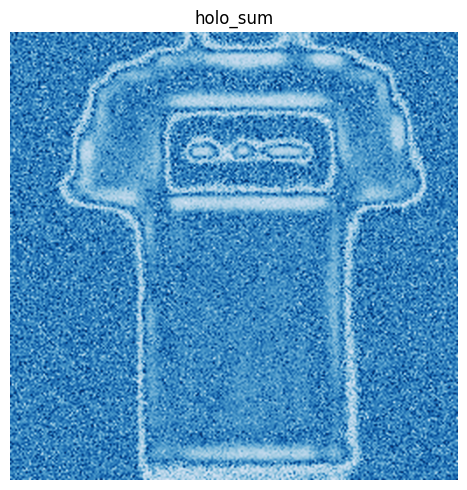

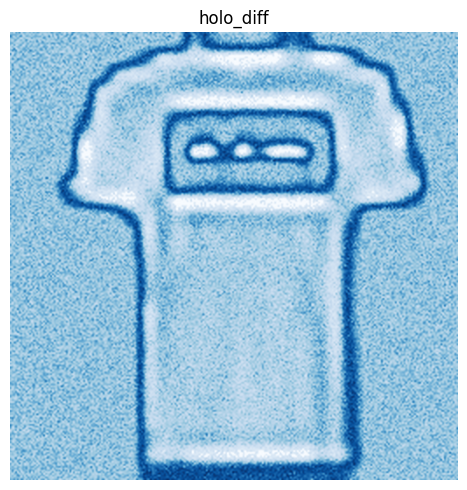

Saved files:
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\target_raw16.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\target_preview.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\T_raw16.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\T_preview.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\gamma_raw16.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\gamma_preview.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\holo_constructive_raw16.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\holo_constructive_preview.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\holo_destructive_raw16.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\holo_destructive_preview.png
C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs\holo_sum_raw16.png
C:\Users\R

In [8]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter
import warnings

warnings.filterwarnings("ignore")


class QIUPSingleImageDataset(Dataset):
    def __init__(
        self,
        image_path,
        img_size=512,
        output_size=256,
        visibility=0.77,
        mean_photons=300,
        qe=0.95,
        em_gain=800,
        cic_rate=0.002,
        read_noise_sigma=0.5,
        preamp_gain=2.0,
        phase_stability=0.9,
        background_threshold=0.12,
        signal_threshold=0.05,
        add_shot_noise=True,
        add_cic=True,
        add_read_noise=True,
        add_phase_disturbance=True,
    ):
        self.image_path = image_path
        self.img_size = img_size
        self.output_size = output_size
        self.visibility = visibility
        self.mean_photons = mean_photons
        self.qe = qe
        self.em_gain = em_gain
        self.cic_rate = cic_rate
        self.read_noise_sigma = read_noise_sigma
        self.preamp_gain = preamp_gain
        self.phase_stability = phase_stability
        self.background_threshold = background_threshold
        self.signal_threshold = signal_threshold
        self.add_shot_noise = add_shot_noise
        self.add_cic = add_cic
        self.add_read_noise = add_read_noise
        self.add_phase_disturbance = add_phase_disturbance

        self.transform = transforms.Compose([
            transforms.Resize((self.output_size, self.output_size), Image.LANCZOS),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor()
        ])

        img = Image.open(self.image_path).convert("L")
        self.image_tensor = self.transform(img)

    def __len__(self):
        return 1

    def prepare_object_properties(self, image):
        img_norm = (image - image.min()) / (image.max() - image.min() + 1e-8)
        T = np.clip(img_norm * 0.8 + 0.2, 0, 1)
        gamma = 2 * np.pi * (img_norm - 0.5)
        return T, gamma

    def generate_phase_disturbance(self, shape):
        h, w = shape
        x = np.linspace(0, 2 * np.pi, w)
        y = np.linspace(0, 2 * np.pi, h)
        X, Y = np.meshgrid(x, y)
        disturbance = 0.02 * np.sin(X) + 0.02 * np.sin(Y)
        random_phase = np.random.randn(h, w) * 0.03
        random_phase = gaussian_filter(random_phase, sigma=4)
        return (disturbance + random_phase) * (1 - self.phase_stability) * 0.3

    def apply_nature_style_threshold(self, hologram, T):
        processed = hologram.copy()
        signal_mask = T > self.signal_threshold
        processed[processed < self.background_threshold] = 0
        processed[~signal_mask] = 0

        if signal_mask.any():
            vmin = processed[signal_mask].min()
            vmax = processed[signal_mask].max()
            if vmax > vmin:
                processed[signal_mask] = (processed[signal_mask] - vmin) / (vmax - vmin)

        return processed

    def apply_emccd_noise(self, intensity, T):
        photons = intensity * self.mean_photons
        electrons = photons * self.qe

        if self.add_shot_noise:
            electrons = np.random.poisson(electrons)

        if self.add_cic:
            cic = np.random.poisson(self.cic_rate, size=electrons.shape)
            electrons = electrons + cic * (T > self.signal_threshold)

        if self.em_gain > 1:
            excess_noise = np.random.gamma(2, 0.5, electrons.shape)
            effective_gain = self.em_gain * (0.8 + 0.2 * excess_noise)
            electrons = electrons * effective_gain

        if self.add_read_noise:
            electrons = electrons + np.random.randn(*electrons.shape) * self.read_noise_sigma

        electrons = np.maximum(electrons, 0)
        adu = np.clip(electrons / self.preamp_gain, 0, 65535)
        hologram = adu.astype(np.float32) / 65535.0
        return self.apply_nature_style_threshold(hologram, T)

    def simulate_three_outputs(self, T, gamma):
        if self.add_phase_disturbance:
            phase = gamma + self.generate_phase_disturbance(T.shape)
        else:
            phase = gamma

        I_constructive = 0.5 * (1 + self.visibility * T * np.cos(phase))
        I_destructive = 0.5 * (1 + self.visibility * T * np.cos(phase + np.pi))

        holo_c = self.apply_emccd_noise(I_constructive, T)
        holo_d = self.apply_emccd_noise(I_destructive, T)
        holo_sum = self.apply_nature_style_threshold((holo_c + holo_d) / 2, T)
        holo_diff = self.apply_nature_style_threshold((holo_c - holo_d) / 2 + 0.5, T)

        return holo_c, holo_d, holo_sum, holo_diff

    def __getitem__(self, idx):
        img_np = self.image_tensor.squeeze().numpy()
        T, gamma = self.prepare_object_properties(img_np)
        holo_c, holo_d, holo_sum, holo_diff = self.simulate_three_outputs(T, gamma)

        def resize_image(arr):
            return np.array(
                Image.fromarray((arr * 65535).astype(np.uint16)).resize(
                    (self.img_size, self.img_size), Image.LANCZOS
                )
            ) / 65535.0

        return {
            "target": torch.FloatTensor(img_np).unsqueeze(0),
            "T": torch.FloatTensor(T).unsqueeze(0),
            "gamma": torch.FloatTensor((gamma + np.pi) / (2 * np.pi)).unsqueeze(0),
            "holo_constructive": torch.FloatTensor(resize_image(holo_c)).unsqueeze(0),
            "holo_destructive": torch.FloatTensor(resize_image(holo_d)).unsqueeze(0),
            "holo_sum": torch.FloatTensor(resize_image(holo_sum)).unsqueeze(0),
            "holo_diff": torch.FloatTensor(resize_image(holo_diff)).unsqueeze(0),
            "label": 0,
        }


def convert_to_andor_style(image):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy()
    cmap = plt.get_cmap("Blues")
    return (cmap(image)[:, :, :3] * 255).astype(np.uint8)


def _to_numpy_2d(x):
    if isinstance(x, torch.Tensor):
        x = x.squeeze().detach().cpu().numpy()
    else:
        x = np.squeeze(x)
    return x


def _save_gray_16bit(arr, path):
    arr = np.clip(arr, 0.0, 1.0)
    arr16 = (arr * 65535).astype(np.uint16)
    Image.fromarray(arr16, mode="I;16").save(path)


def _save_rgb_8bit(arr_rgb, path):
    arr_rgb = np.clip(arr_rgb, 0, 255).astype(np.uint8)
    Image.fromarray(arr_rgb, mode="RGB").save(path)


def save_outputs_separately(sample, out_dir="single_outputs", show=True):
    os.makedirs(out_dir, exist_ok=True)

    target = _to_numpy_2d(sample["target"])
    T = _to_numpy_2d(sample["T"])
    gamma = _to_numpy_2d(sample["gamma"])
    holo_c = _to_numpy_2d(sample["holo_constructive"])
    holo_d = _to_numpy_2d(sample["holo_destructive"])
    holo_sum = _to_numpy_2d(sample["holo_sum"])
    holo_diff = _to_numpy_2d(sample["holo_diff"])

    items = [
        ("target", target, "gray"),
        ("T", T, "gray"),
        ("gamma", gamma, "twilight"),
        ("holo_constructive", holo_c, "andor"),
        ("holo_destructive", holo_d, "andor"),
        ("holo_sum", holo_sum, "andor"),
        ("holo_diff", holo_diff, "andor"),
    ]

    saved_paths = []

    for name, arr, style in items:
        raw_path = os.path.join(out_dir, f"{name}_raw16.png")
        _save_gray_16bit(arr, raw_path)
        saved_paths.append(raw_path)

        preview_path = os.path.join(out_dir, f"{name}_preview.png")
        if style == "andor":
            rgb = convert_to_andor_style(arr)
            _save_rgb_8bit(rgb, preview_path)
        else:
            plt.imsave(preview_path, arr, cmap=style, vmin=0, vmax=1)
        saved_paths.append(preview_path)

        if show:
            plt.figure(figsize=(5, 5))
            if style == "andor":
                plt.imshow(convert_to_andor_style(arr))
            else:
                plt.imshow(arr, cmap=style, vmin=0, vmax=1)
            plt.title(name)
            plt.axis("off")
            plt.tight_layout()
            plt.show()

    print("Saved files:")
    for p in saved_paths:
        print(p)

    return saved_paths


def show_main_result(sample):
    img = _to_numpy_2d(sample["target"])
    diff = _to_numpy_2d(sample["holo_diff"])

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(convert_to_andor_style(diff))
    plt.title("Hologram Difference")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    image_path = r"C:\Users\Ryan\Desktop\quantom_project\quantom_project\smooth0.png"

    dataset = QIUPSingleImageDataset(
        image_path=image_path,
        img_size=512,
        output_size=256,
        visibility=0.77,
        mean_photons=300,
        background_threshold=0.12,
        signal_threshold=0.05
    )

    sample = dataset[0]

    show_main_result(sample)

    save_outputs_separately(
        sample,
        out_dir=r"C:\Users\Ryan\Desktop\quantom_project\quantom_project\saved_outputs",
        show=True
    )